In [1]:
import elecboltz
# IMPORTANT: this example depends on the cuprates_transport package
# https://github.com/gaelgrissonnanche/cuprates_transport
from cuprates_transport.bandstructure import BandStructure
from cuprates_transport.conductivity import Conductivity

import numpy as np
from scipy.constants import e, m_e, hbar, electron_volt

import matplotlib as mpl
from matplotlib import pyplot as plt

In [3]:
# matplotlib settings
# reset defaults
mpl.rcdefaults()
# font
mpl.rcParams['font.size'] = 20
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['legend.fontsize'] = 'small'
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['pdf.fonttype'] = 3
# plotting
mpl.rcParams['figure.figsize'] = (7.48, 5.0)
mpl.rcParams['lines.linewidth'] = 3
mpl.rcParams['lines.markersize'] = 20

In [23]:
def calculate_drude(effective_mass, charge_density,
                    scattering_rate, magnetic_field):
    charge_mass = m_e * effective_mass
    omega_c = e * magnetic_field / charge_mass
    inverse_tensor = np.zeros((3, 3))
    np.fill_diagonal(inverse_tensor, scattering_rate)
    inverse_tensor[0, 1] = omega_c[2]
    inverse_tensor[1, 0] = -omega_c[2]
    inverse_tensor[0, 2] = -omega_c[1]
    inverse_tensor[2, 0] = omega_c[1]
    inverse_tensor[1, 2] = omega_c[0]
    inverse_tensor[2, 1] = -omega_c[0]
    return charge_density * e**2 / charge_mass * np.linalg.inv(inverse_tensor)

In [24]:
dispersion = "Ef * (kx^2 + ky^2 + kz^2)"
kf=1e10
a = np.pi / kf * 1e10
coeff = hbar**2 / (2*m_e)
Ef = coeff * kf**2 / electron_volt * 1e3

In [25]:
resolutions = np.arange(10, 61, dtype=int)
sigma_xx_no_correction = np.empty_like(resolutions, dtype=float)
sigma_xx_corrected = np.empty_like(resolutions, dtype=float)
for i, resolution in enumerate(resolutions):
    bandstructure = elecboltz.BandStructure(
        dispersion=dispersion, chemical_potential=Ef, unit_cell=[a, a, a],
        band_params={'Ef': Ef}, resolution=resolution, periodic=False)
    bandstructure.discretize()
    conductivity = elecboltz.Conductivity(bandstructure, scattering_rate=1.0,
                                          correct_curvature=False)
    sigma_xx_no_correction[i] = conductivity.calculate(i=0, j=0)
for i, resolution in enumerate(resolutions):
    bandstructure = elecboltz.BandStructure(
        dispersion=dispersion, chemical_potential=Ef, unit_cell=[a, a, a],
        band_params={'Ef': Ef}, resolution=resolution, periodic=False)
    bandstructure.discretize()
    conductivity = elecboltz.Conductivity(bandstructure, scattering_rate=1.0,
                                          correct_curvature=True)
    sigma_xx_corrected[i] = conductivity.calculate(i=0, j=0)

/tmp/ipykernel_73592/334667115.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_xx_no_correction[i] = conductivity.calculate(i=0, j=0)
/tmp/ipykernel_73592/334667115.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sigma_xx_corrected[i] = conductivity.calculate(i=0, j=0)


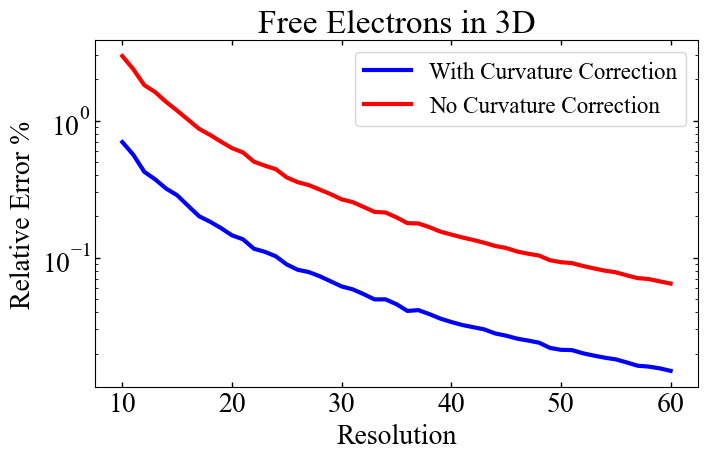

In [ ]:
drude_sigma = kf**3 / (3 * np.pi**2) * e**2 / m_e / 1e12
plt.plot(
    resolutions, np.abs(sigma_xx_corrected / drude_sigma - 1.0) * 100.0,
    color='blue', label="With Curvature Correction")
plt.plot(
    resolutions, np.abs(sigma_xx_no_correction / drude_sigma - 1.0) * 100.0,
    color='red', label="No Curvature Correction")
plt.yscale('log')
plt.ylabel(r"Relative Error %")
plt.xlabel("Resolution")
plt.title("Free Electrons in 3D")
plt.legend()
plt.tight_layout()
plt.savefig("curvature_correction_convergence_comparison.pdf")
plt.show()

In [4]:
params_chambers = {
    'band_name': "Nd-LSCO",
    'a': 3.75,
    'b': 3.75,
    'c': 13.2,
    'energy_scale': 160,
    'band_params': {'mu': -0.82439881, 't': 1, 'tp': -0.13642799,
                    'tpp': 0.06816836, 'tz': 0.06512192},
    'k_max': [np.pi, np.pi, 2*np.pi],
    'N_time': 1000,
    'Bamp': 45,
    'scattering_models': ['isotropic', 'cos2phi'],
    'scattering_params': {'gamma_0': 12.595, 'gamma_k': 63.823, 'power': 12},
}

In [5]:
params_fem = params_chambers.copy()
params_fem['domain_size'] = [1.0, 1.0, 2.0]
params_fem['periodic'] = 2
params_fem = elecboltz.easy_params(params_fem)

In [6]:
resolutions = np.arange(21, 55, 2)
rho_zz_chambers = np.empty_like(resolutions, dtype=float)
rho_zz_fem = np.empty_like(resolutions, dtype=float)

for i, resolution in enumerate(resolutions):
    params_chambers['resolution'] = [resolution, resolution, resolution]
    band_chambers = BandStructure(**params_chambers)
    band_chambers.runBandStructure()
    cond_chambers = Conductivity(band_chambers, **params_chambers)
    cond_chambers.runTransport()
    rho_chambers = np.linalg.inv(cond_chambers.sigma)
    rho_zz_chambers[i] = rho_chambers[2, 2]

    params_fem['resolution'] = resolution
    band_fem = elecboltz.BandStructure(**params_fem)
    band_fem.discretize()
    cond_fem = elecboltz.Conductivity(band_fem, **params_fem)
    rho_fem = np.linalg.inv(cond_fem.calculate())
    rho_zz_fem[i] = rho_fem[2, 2]

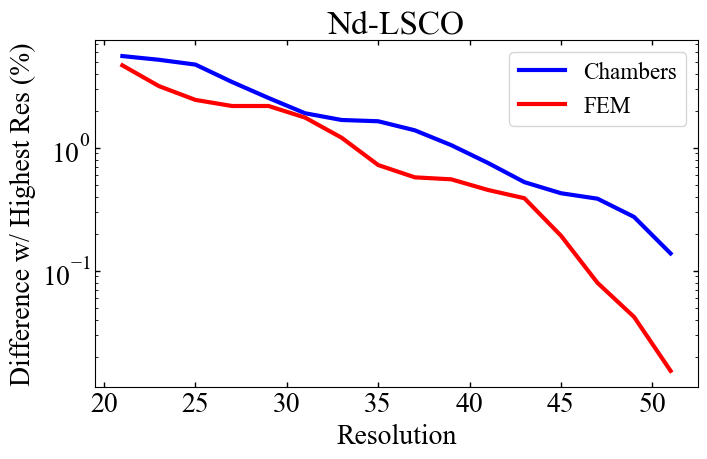

In [ ]:
plt.plot(
    resolutions[:-1],
    np.abs(rho_zz_chambers[:-1] / rho_zz_chambers[-1] - 1.0) * 100.0,
    color='blue', label="Chambers")
plt.plot(
    resolutions[:-1],
    np.abs(rho_zz_fem[:-1] / rho_zz_fem[-1] - 1.0) * 100.0,
    color='red', label="FEM")
plt.yscale('log')
plt.ylabel(r"Difference w/ Highest Res (%)")
plt.xlabel("Resolution")
plt.title("Nd-LSCO")
plt.legend()
plt.tight_layout()
plt.savefig("fem_vs_chambers_convergence.pdf")
plt.show()